# University Query Management System

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
train_df = pd.read_csv("university_query_train.csv")
test_df = pd.read_csv("university_query_test.csv")

print(train_df.shape)
train_df.head()

(5000, 5)


,Query_ID,Student_Query,Department,Days_To_Deadline,Priority_Label
0,1783,How to join student clubs?,Examination Cell,31,Low
1,3918,My admit card has incorrect details.,Examination Cell,48,High
2,222,How to reset my university portal password?,Finance Office,5,Medium
3,2136,My exam form is not submitted and tomorrow is ...,Academic Office,18,High
4,5225,I cannot download my hall ticket for tomorrow'...,Administration,43,High


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Query_ID          5000 non-null   int64 
 1   Student_Query     5000 non-null   object
 2   Department        5000 non-null   object
 3   Days_To_Deadline  5000 non-null   int64 
 4   Priority_Label    5000 non-null   object
dtypes: int64(2), object(3)
memory usage: 195.4+ KB


In [4]:
train_df.describe()

,Query_ID,Days_To_Deadline
count,5000.000000,5000.000000
mean,2984.546200,30.602000
std,1736.118606,17.181648
min,1.000000,1.000000
25%,1469.750000,16.000000
50%,2986.500000,31.000000
75%,4478.250000,46.000000
max,6000.000000,60.000000


In [5]:
train_df.isnull().sum()

Query_ID            0
Student_Query       0
Department          0
Days_To_Deadline    0
Priority_Label      0
dtype: int64

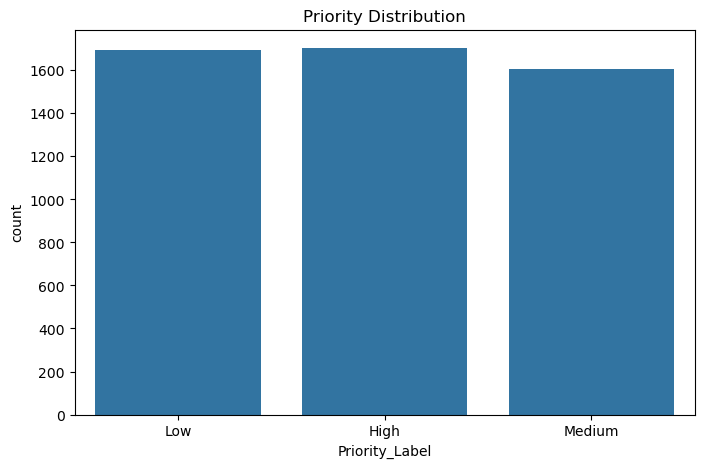

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(x='Priority_Label', data=train_df)
plt.title("Priority Distribution")
plt.show()

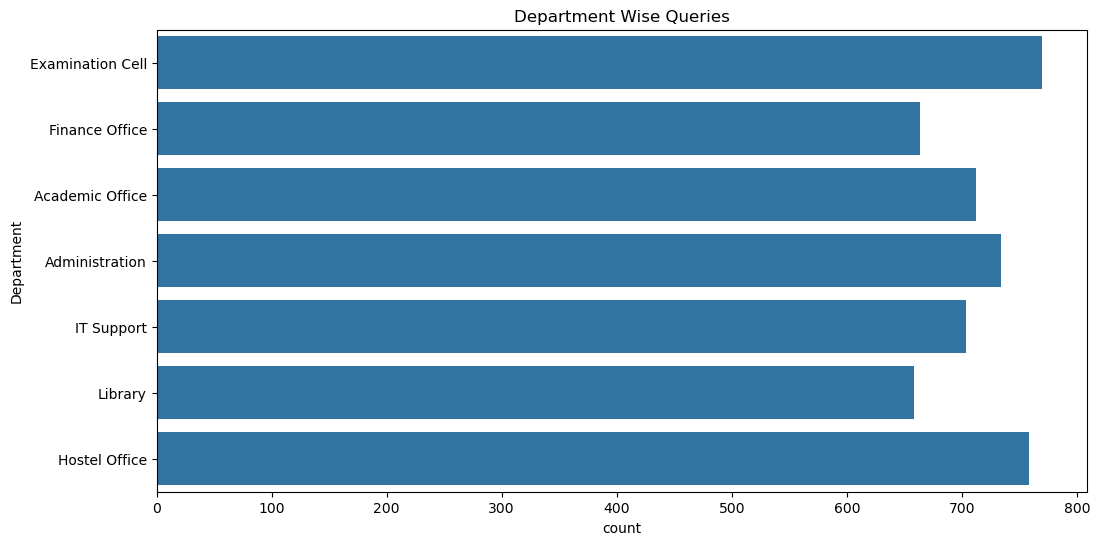

In [8]:
plt.figure(figsize=(12,6))
sns.countplot(y='Department', data=train_df)
plt.title("Department Wise Queries")
plt.show()

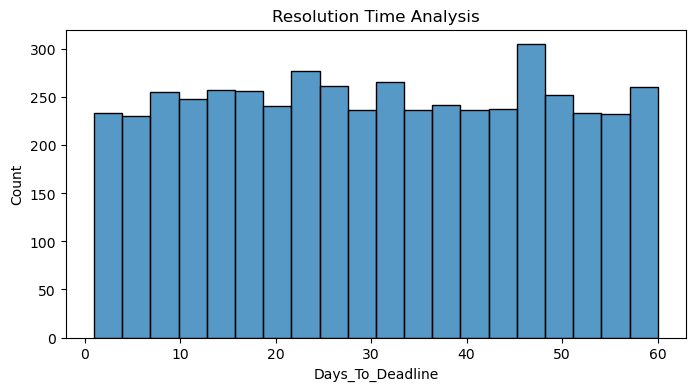

In [29]:
plt.figure(figsize=(8,4))
sns.histplot(train_df['Days_To_Deadline'], bins=20)
plt.title("Resolution Time Analysis")
plt.show()

In [9]:
def clean_text(text):
    
    text = str(text).lower()
    
    text = re.sub(r'[^a-zA-Z ]', '', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    return text

train_df['Clean_Query'] = train_df['Student_Query'].apply(clean_text)

test_df['Clean_Query'] = test_df['Student_Query'].apply(clean_text)

In [10]:
X_train = train_df['Clean_Query']

y_train = train_df['Priority_Label']

X_test = test_df['Clean_Query']

y_test = test_df['Priority_Label']

In [11]:
model = Pipeline([
    
    ('tfidf', TfidfVectorizer()),
    
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
    
])

In [12]:
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [13]:
predictions = model.predict(X_test)

In [30]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy :", round(accuracy*100,2), "%")

Accuracy : 100.0 %


In [15]:
print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       329
         Low       1.00      1.00      1.00       360
      Medium       1.00      1.00      1.00       311

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



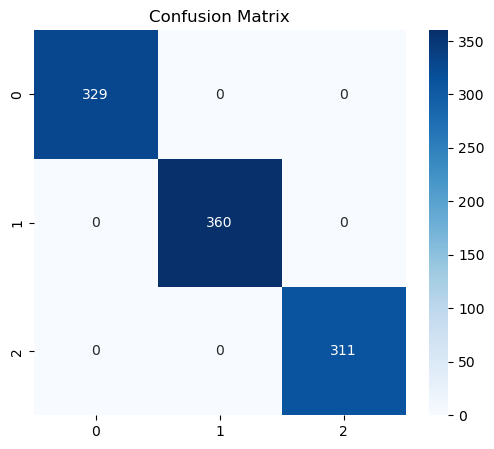

In [16]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.show()

In [17]:
department_mapping = {

    "fee":"Finance Department",

    "scholarship":"Finance Department",

    "exam":"Examination Cell",

    "hostel":"Hostel Office",

    "wifi":"IT Support",

    "library":"Library",

    "admission":"Admission Cell"

}

In [18]:
def route_department(query):
    
    query = query.lower()
    
    for key, value in department_mapping.items():
        
        if key in query:
            
            return value
    
    return "Administration"

In [37]:
def generate_auto_response(query):

    query = query.lower()

    if "scholarship" in query:

        return """
Your scholarship-related query has been forwarded to the Finance Department.
Expected resolution time: 2-3 working days.
"""

    elif "fee" in query:

        return """
Your fee-related query has been registered successfully.
Please keep your payment receipt for verification.
"""

    elif "exam" in query:

        return """
Your examination query has been forwarded to the Examination Cell.
You will receive an update shortly.
"""

    elif "result" in query:

        return """
Your result-related query has been registered.
The Examination Department will review your request.
"""

    elif "hostel" in query:

        return """
Your hostel complaint has been forwarded to the Hostel Administration.
Necessary action will be taken soon.
"""

    elif "wifi" in query or "internet" in query:

        return """
Your internet/WiFi issue has been sent to the IT Support Team.
Please allow some time for troubleshooting.
"""

    elif "library" in query:

        return """
Your library-related query has been forwarded to the Library Department.
"""

    elif "admission" in query:

        return """
Your admission-related query has been registered successfully.
"""

    elif "placement" in query:

        return """
Your placement-related query has been forwarded to the Placement Cell.
"""

    else:

        return """
Thank you for contacting the University Helpdesk.
Your query has been registered and will be reviewed soon.
"""

In [32]:
import random
def generate_ticket():

    return "TKT" + str(random.randint(1000,9999))

In [33]:
def summarize_query(query):

    words = query.split()

    return " ".join(words[:8]) + "..."

In [38]:
def university_chatbot(query):

    ticket_id = generate_ticket()

    department = route_department(query)

    response = generate_auto_response(query)

    summary = summarize_query(query)

    print("="*70)

    print("TICKET ID :", ticket_id)

    print("\nSTUDENT QUERY:")
    print(query)

    print("\nQUERY SUMMARY:")
    print(summary)

    print("\nASSIGNED DEPARTMENT:")
    print(department)

    print("\nAUTO RESPONSE:")
    print(response)

    print("="*70)

In [39]:
university_chatbot(
    "I am unable to submit my examination form"
)

TICKET ID : TKT2108

STUDENT QUERY:
I am unable to submit my examination form

QUERY SUMMARY:
I am unable to submit my examination form...

ASSIGNED DEPARTMENT:
Examination Cell

AUTO RESPONSE:

Your examination query has been forwarded to the Examination Cell.
You will receive an update shortly.



In [21]:
university_chatbot(
    "My scholarship has not been credited yet"
)

Department : Finance Department
Priority : High
Response : Your issue has been marked HIGH priority and forwarded immediately.


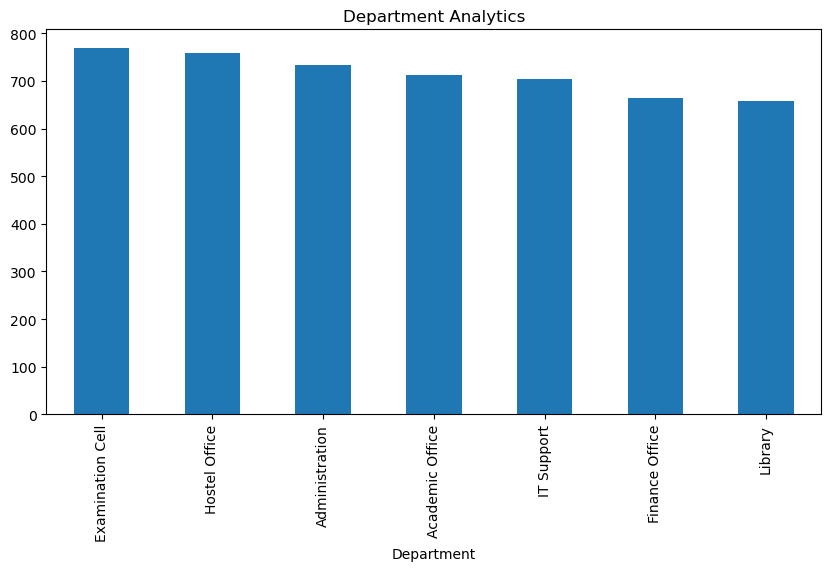

In [34]:
train_df['Department'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Department Analytics")
plt.show()

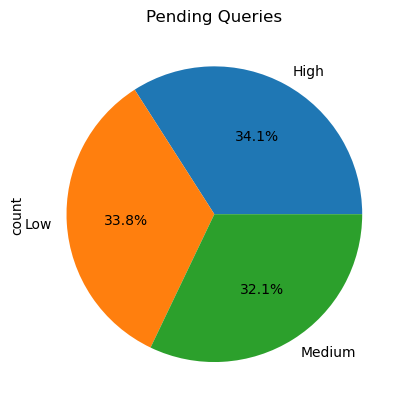

In [35]:
train_df['Priority_Label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Pending Queries")
plt.show()

In [36]:
from collections import Counter

words = " ".join(
    train_df['Clean_Query']
)

top_words = Counter(words.split())

print(top_words.most_common(20))

[('is', 2034), ('my', 2009), ('not', 1373), ('i', 1335), ('the', 1014), ('for', 995), ('to', 985), ('portal', 697), ('working', 692), ('university', 687), ('what', 681), ('how', 674), ('exam', 673), ('have', 369), ('received', 369), ('scholarship', 369), ('amount', 369), ('fee', 351), ('payment', 351), ('deadline', 351)]
